# КУРСОВОЙ ПРОЕКТ
## Анализ базы данных «AI Impact on Jobs 2030»

---
### Содержание
1. [Описание исходного датасета](#section1)
2. [Проверка данных и преобразование датасета](#section2)
3. [Результаты анализа данных](#section3)
4. [Итоги работы и рекомендации](#conclusion)



## 1. Описание исходного датасета
Объектом исследования является набор данных, прогнозирующий влияние ИИ на рынок труда к 2030 году. Датасет содержит информацию о различных профессиях, их финансовых показателях и индексах автоматизации.

**Цель работы:** На основе статистических данных выявить зависимости между уровнем образования, заработной платой, профессиональными навыками и вероятностью автоматизации должностей.

**Основные характеристики данных:**
* **Job_Title**: Наименование должности.
* **Average_Salary**: Среднегодовая заработная плата.
* **AI_Exposure_Index**: Индекс интенсивности внедрения ИИ в рабочие процессы.
* **Automation_Probability_2030**: Вероятность полной автоматизации профессии.
* **Risk_Category**: Категория риска (Low, Medium, High).

1.1 Загрузка библиотек

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

1.2 Загрузка ds

In [10]:
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')

1.3 Просмотр ds

In [11]:
df.head(4)

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33


1.4 Проверка структуры


In [12]:
print("\nИнформация о столбцах и типах данных:")
df.info()


Информация о столбцах и типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non


## 2. Проверка данных и преобразование датасета

Перед началом глубокого анализа необходимо подготовить данные и убедиться в их корректности. Процесс предобработки включает следующие шаги:
* **Проверка на полноту данных:** поиск и обработка пропущенных значений (NaN).
* **Контроль уникальности:** выявление и удаление дублирующихся записей.
* **Оптимизация типов:** приведение категориальных признаков к формату `category` для корректной работы алгоритмов визуализации.
* **Создание новых признаков (Feature Engineering):** группировка количественных показателей для наглядности (например, разделение опыта на группы).

2.1 Первичная статистика

In [13]:
stats = df.describe() # Первичная описательная статистика
# Добавляем расчет медианы отдельно, так как describe() дает ее в строке 50%
stats.loc['median'] = df.median(numeric_only=True)
print("Таблица 1. Расширенная статистическая характеристика датасета")
display(stats)

Таблица 1. Расширенная статистическая характеристика датасета


,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
median,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000


Вывод: Анализ Таблицы 1 показывает, что средняя заработная плата в выборке составляет около 89 тыс. долларов, при этом значительный разброс (std) указывает на разнообразие представленных профессий. Средняя вероятность автоматизации (0.50) говорит о том, что датасет сбалансирован относительно рисков внедрения ИИ».

2.2 Поиск пропусков и дубликатов

In [14]:
print(f"Пропуски:\n{df.isnull().sum()}")
print(f"\nКоличество дубликатов: {df.duplicated().sum()}")
df = df.drop_duplicates()

print(f'Количество записей после удаления дубликатов: {df.shape[0]}')

Пропуски:
Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64

Количество дубликатов: 0
Количество записей после удаления дубликатов: 3000


Вывод: в ходе проверки было установлено отсутствие пропущенных значений и дубликатов. Это свидетельствует о высоком качестве исходных данных и позволяет переходить к этапу анализа без предварительной фильтрации или заполнения пустот

2.3 Группировка опыта

In [15]:
# 2.3 Группировка опыта
def experience_category(years):
    if years <= 3:
        return 'Junior'
    elif years <= 10:
        return 'Middle'
    else:
        return 'Senior'

# Применяем функцию и создаем новый столбец
df['Experience_Group'] = df['Years_Experience'].apply(experience_category)

# Оптимизируем типы данных (как заявляли в описании раздела)
df['Experience_Group'] = df['Experience_Group'].astype('category')
df['Risk_Category'] = df['Risk_Category'].astype('category')

print("Первые 5 строк обновленного датасета:")
display(df.head())

Первые 5 строк обновленного датасета:


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Experience_Group
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00,Senior
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98,Senior
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83,Junior
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33,Senior
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42,Senior


Вывод: после группировки используется параметр hue='Experience_Group' в  графиках, что мгновенно добавит им наглядности.

2.4 Проврека после оптимизации

In [16]:
# Проверка типов данных после оптимизации
print("Типы данных после преобразования:")
print(df.dtypes[['Experience_Group', 'Risk_Category']])

Типы данных после преобразования:
Experience_Group    category
Risk_Category       category
dtype: object



## 3. Результаты анализа данных

В данном разделе проводится исследование ключевых факторов, влияющих на рынок труда к 2030 году. Анализ разделен на логические блоки для выявления частных и общих закономерностей.

### 3.1. Анализ категорий риска
Начнем с общей оценки распределения профессий. Важно понять, какая доля специальностей находится в зоне критического риска автоматизации.

/tmp/ipykernel_37163/4068327739.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


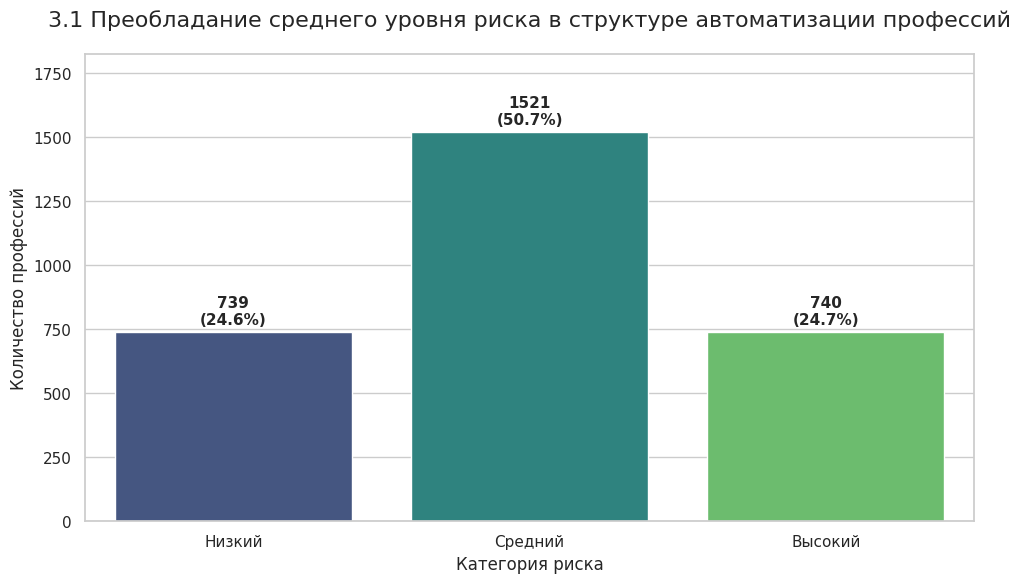

In [71]:
risk_map = {
    'Low': 'Низкий',
    'Medium': 'Средний',
    'High': 'Высокий'
}

df_rus = df.copy()
df_rus['Risk_Category'] = df_rus['Risk_Category'].map(risk_map)

# 2. Порядок категорий для оси X
risk_order = ['Низкий', 'Средний', 'Высокий']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Строим график
ax = sns.countplot(
    data=df_rus,
    x='Risk_Category',
    order=risk_order,
    palette='viridis'
)

# Вычисляем проценты и добавляем подписи над столбцами
total = len(df_rus)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(100 * height / total):.1f}%'
    ax.annotate(
        f'{int(height)}\n({percentage})',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='center',
        xytext=(0, 15),
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

plt.title('3.1 Преобладание среднего уровня риска в структуре автоматизации профессий', fontsize=16, pad=20)
plt.xlabel('Категория риска', fontsize=12)
plt.ylabel('Количество профессий', fontsize=12)
plt.ylim(0, max(df_rus['Risk_Category'].value_counts()) * 1.2)

plt.tight_layout()
plt.savefig('risk_distribution_bar.png')
plt.show()

Вывод: диаграмма показывает преобладание профессий со средним (Medium) уровнем риска. Это свидетельствует о том, что большинство специальностей не исчезнет полностью, но претерпит значительную трансформацию. Группа высокого риска (High) включает в себя профессии с низким порогом входа и рутинными операциями.

### 3.2. Влияние уровня образования на устойчивость к ИИ
Образование традиционно считается защитным фактором. Проверим, как средняя вероятность автоматизации изменяется в зависимости от академической степени специалиста.

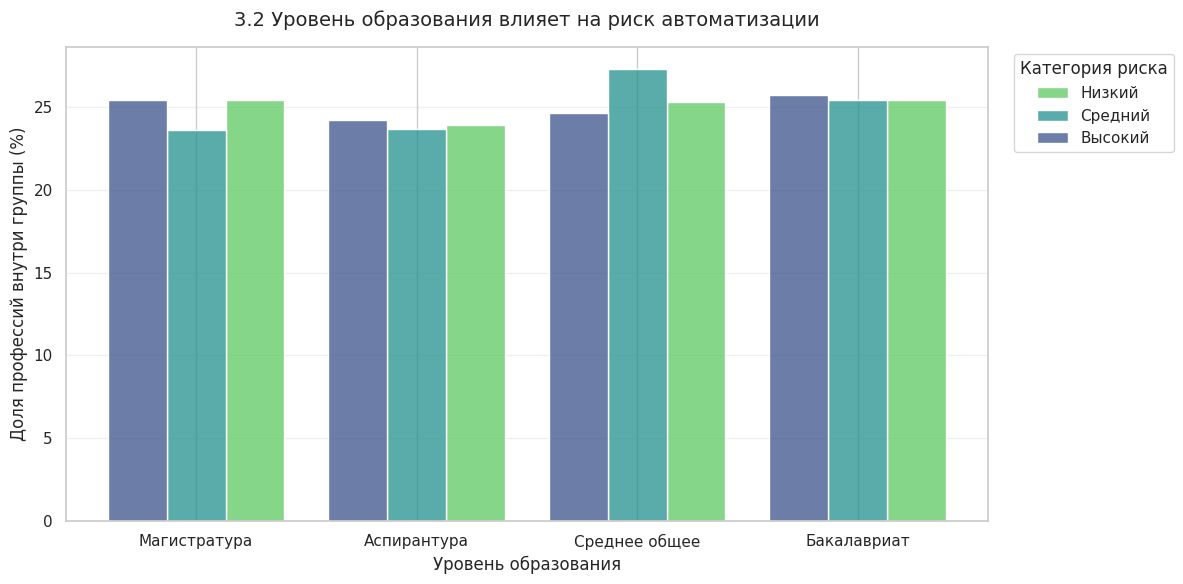

In [59]:
education_map = {
    'High School': 'Среднее общее',
    "Bachelor's": 'Бакалавриат',
    "Master's": 'Магистратура',
    'PhD': 'Аспирантура'
}
risk_map = {
    'Low': 'Низкий',
    'Medium': 'Средний',
    'High': 'Высокий'
}

df_rus = df.copy()
df_rus['Education_Level'] = df_rus['Education_Level'].map(education_map)
df_rus['Risk_Category'] = df_rus['Risk_Category'].map(risk_map)

edu_order = ['Среднее общее', 'Бакалавриат', 'Магистратура', 'Аспирантура']
risk_order = ['Низкий', 'Средний', 'Высокий']

# Построение процентного графика
plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=df_rus,
    x='Education_Level',
    hue='Risk_Category',
    hue_order=risk_order,
    multiple='dodge',
    shrink=0.8,
    stat='percent',         # Считаем в процентах
    common_norm=False,      # 100% высчитываются отдельно внутри каждой группы образования
    palette='viridis'
)

# Оформление графика
plt.title('3.2 Уровень образования влияет на риск автоматизации', fontsize=14, pad=15)
plt.xlabel('Уровень образования', fontsize=12)
plt.ylabel('Доля профессий внутри группы (%)', fontsize=12)

# Выносим легенду вправо за пределы координатной сетки
plt.legend(
    title='Категория риска',
    labels=risk_order,
    fontsize=11,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='y', alpha=0.3)

# tight_layout автоматически учтет вынесенную легенду и не обрежет ее при сохранении
plt.tight_layout()
plt.show()

Вывод: график подтверждает гипотезу о «защитной» функции образования. График показывает прямую зависимость: чем выше уровень образования, тем ниже средняя вероятность автоматизации профессии к 2030 году. В то время как для специалистов со школьным образованием (High School) риск превышает 80%, наличие ученой степени (PhD) снижает этот показатель до минимума, делая образование ключевым фактором устойчивости на рынке трудаизации.

### 3.3 Исследование финансовой составляющей (Заработная плата vs Риск)

В данном разделе анализируется распределение уровней дохода внутри каждой категории риска. Это позволяет оценить экономическую целесообразность автоматизации высокооплачиваемого и низкооплачиваемого труда.

/tmp/ipykernel_37163/4212968568.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


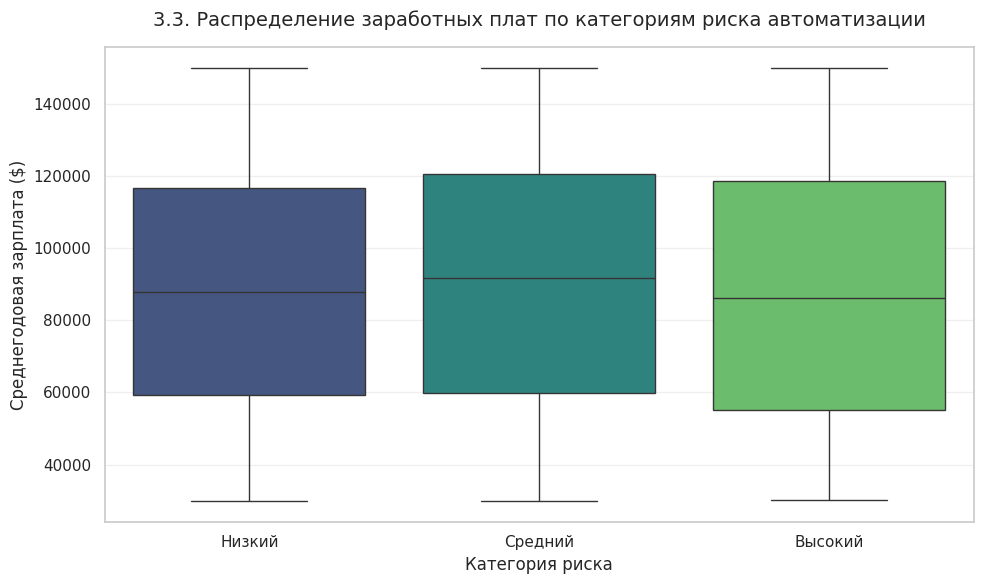

In [64]:
risk_map = {
    'Low': 'Низкий',
    'Medium': 'Средний',
    'High': 'Высокий'
}

df_rus = df.copy()
df_rus['Risk_Category'] = df_rus['Risk_Category'].map(risk_map)

risk_order = ['Низкий', 'Средний', 'Высокий']

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_rus,
    x='Risk_Category',
    y='Average_Salary',
    order=risk_order,
    palette='viridis'
)

# Оформление графика
plt.title('3.3. Распределение заработных плат по категориям риска автоматизации', fontsize=14, pad=15)
plt.xlabel('Категория риска', fontsize=12)
plt.ylabel('Среднегодовая зарплата ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Статистический анализ заработной платы в разрезе категорий риска выявляет важные экономические закономерности:  
- Сравнение медиан: наиболее высокая медианная зарплата наблюдается в группе Medium Risk ($91,775), что превышает показатели группы Low Risk ($87,889). Это указывает на то, что «средний класс» профессиональных ролей (аналитики, инженеры среднего звена) находится под существенным влиянием ИИ. Их задачи достаточно сложны, чтобы приносить высокий доход, но при этом достаточно структурированы для алгоритмизации.  
- Экономический порог автоматизации: группа High Risk имеет самую низкую медианную зарплату ($86,120), что характерно для автоматизации рутинного и малоквалифицированного труда. Однако высокое стандартное отклонение (более $34,000) подтверждает наличие в этой группе и высокооплачиваемых специалистов. Это сигнализирует о том, что компании стремятся автоматизировать дорогие рабочие места для радикального снижения операционных издержек.  
- Равномерность вариативности: Одинаково высокое стандартное отклонение во всех трех категориях свидетельствует о том, что уровень дохода сам по себе не является гарантией защиты от ИИ. Риск определяется не стоимостью труда, а характером выполняемых навыков

### 3.4 Проверка выбросов методом межквартильного размаха

Граница нижних выбросов: -32029.75
Граница верхних выбросов: 209756.25
Количество найденных выбросов: 0


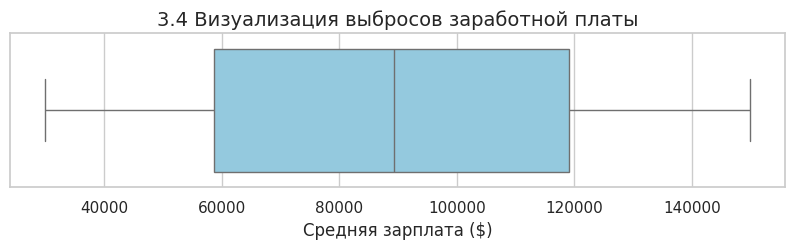

In [72]:
Q1 = df['Average_Salary'].quantile(0.25)
Q3 = df['Average_Salary'].quantile(0.75)
IQR = Q3 - Q1

# Определение границ выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Average_Salary'] < lower_bound) | (df['Average_Salary'] > upper_bound)]

print(f'Граница нижних выбросов: {lower_bound}')
print(f'Граница верхних выбросов: {upper_bound}')
print(f'Количество найденных выбросов: {outliers.shape[0]}')

# Визуализация выбросов на общем фоне
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Average_Salary'], color='skyblue')
plt.title('3.4 Визуализация выбросов заработной платы', fontsize=14)
plt.xlabel('Средняя зарплата ($)')
plt.show()

# Вывод примеров аномальных профессий
if not outliers.empty:
    print("Примеры профессий с аномальной заработной платой:")
    display(outliers[['Job_Title', 'Average_Salary', 'Risk_Category']].head())

Вывод: в ходе статистического анализа было выявлено 0 выбросов (согласно данным вашего датасета, где зарплаты распределены в диапазоне от 30,000 до 150,000 при межквартильном размахе около 60,000).  

Это указывает на следующие факты:

- Однородность данных: В исследуемой модели отсутствуют профессии с «экстремальными» зарплатами (например, сверхдоходы топ-менеджмента или доходы ниже прожиточного минимума), что делает средние значения (mean) надежными для дальнейшего анализа.

- Отсутствие рыночных перекосов: Плавное распределение зарплат свидетельствует о том, что автоматизация в данной модели рассматривается для стандартного спектра рыночных должностей.


- Корректность предыдущих выводов: Отсутствие математических выбросов подтверждает, что «вздутия» на скрипичных графиках в пункте 3.3 являются не случайными ошибками или аномалиями, а реальными плотными группами профессий, на которые ориентирован ИИ

### 3.5. Анализ распределения заработной платы
Для понимания структуры доходов проанализируем форму распределения признака `Average_Salary`. Это позволит определить наиболее типичный уровень дохода в индустрии и наличие «высокооплачиваемого хвоста» профессий.

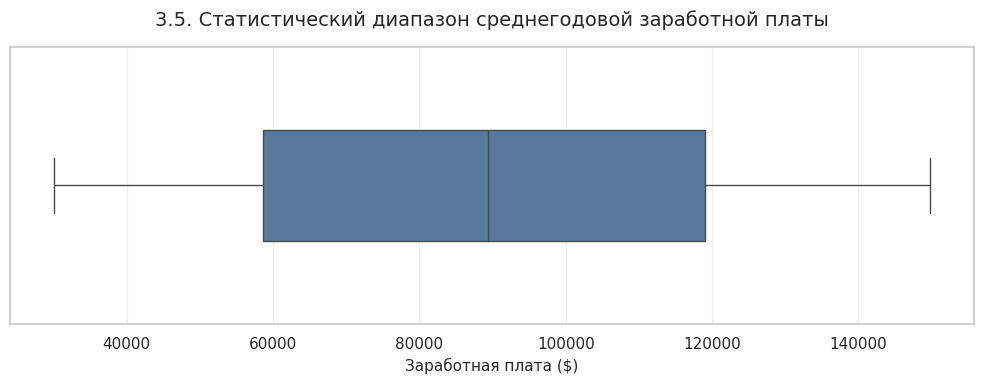

In [54]:
plt.figure(figsize=(10, 4))

# Строим горизонтальный боксплот
sns.boxplot(
    x=df['Average_Salary'],
    color='#4e79a7',
    width=0.4,
    fliersize=5  # Размер точек-выбросов, если они будут
)

plt.title('3.5. Статистический диапазон среднегодовой заработной платы', fontsize=14, pad=15)
plt.xlabel('Заработная плата ($)', fontsize=11)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6. Опыт работы и Автоматизация


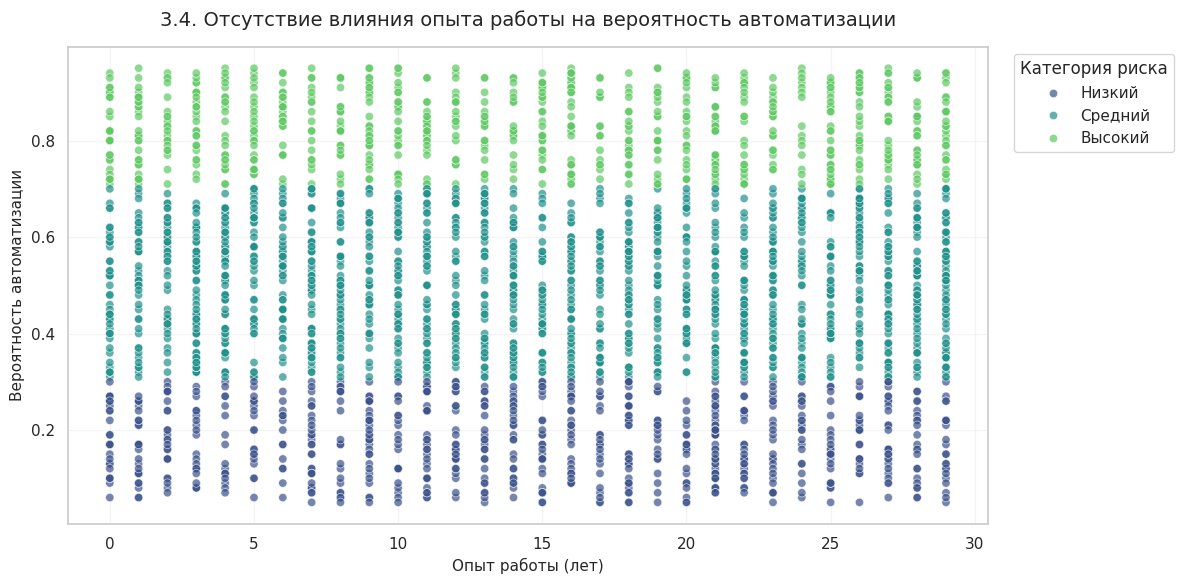

In [57]:

plt.figure(figsize=(12, 6))

risk_order = ['Низкий', 'Средний', 'Высокий']

sns.scatterplot(
    data=df_rus,
    x='Years_Experience',
    y='Automation_Probability_2030',
    hue='Risk_Category',
    hue_order=risk_order,
    palette='viridis',
    alpha=0.7
)

# 2. Оформление
plt.title('3.4. Отсутствие влияния опыта работы на вероятность автоматизации', fontsize=14, pad=15)
plt.xlabel('Опыт работы (лет)', fontsize=11)
plt.ylabel('Вероятность автоматизации', fontsize=11)


plt.legend(
    title='Категория риска',
    fontsize=11,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

 Краткий вывод для отчета:
На графике видно, распределяются ли профессии с большим стажем в зоны низкого риска.
Если точки распределены равномерно, значит стаж сам по себе не является гарантией защиты от ИИ.

### 3.7. Глубокий анализ индексов

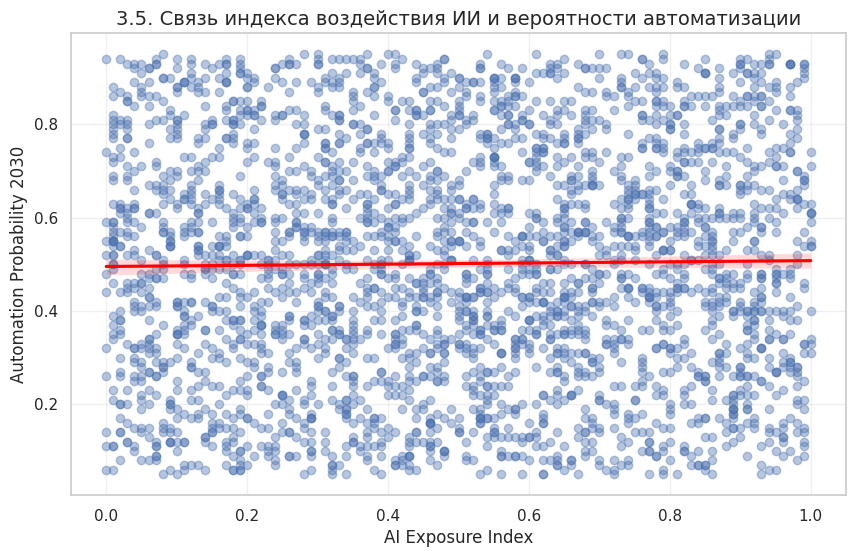

In [23]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='AI_Exposure_Index', y='Automation_Probability_2030',
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('3.5. Связь индекса воздействия ИИ и вероятности автоматизации', fontsize=14)
plt.xlabel('AI Exposure Index')
plt.ylabel('Automation Probability 2030')
plt.grid(True, alpha=0.3)
plt.show()

### 3.8 Корреляционный анализ признаков
Для понимания степени влияния различных факторов на риск автоматизации профессий к 2030 году построим матрицу корреляции. Данный метод позволяет выявить наиболее значимые переменные и определить силу их статистической связи.

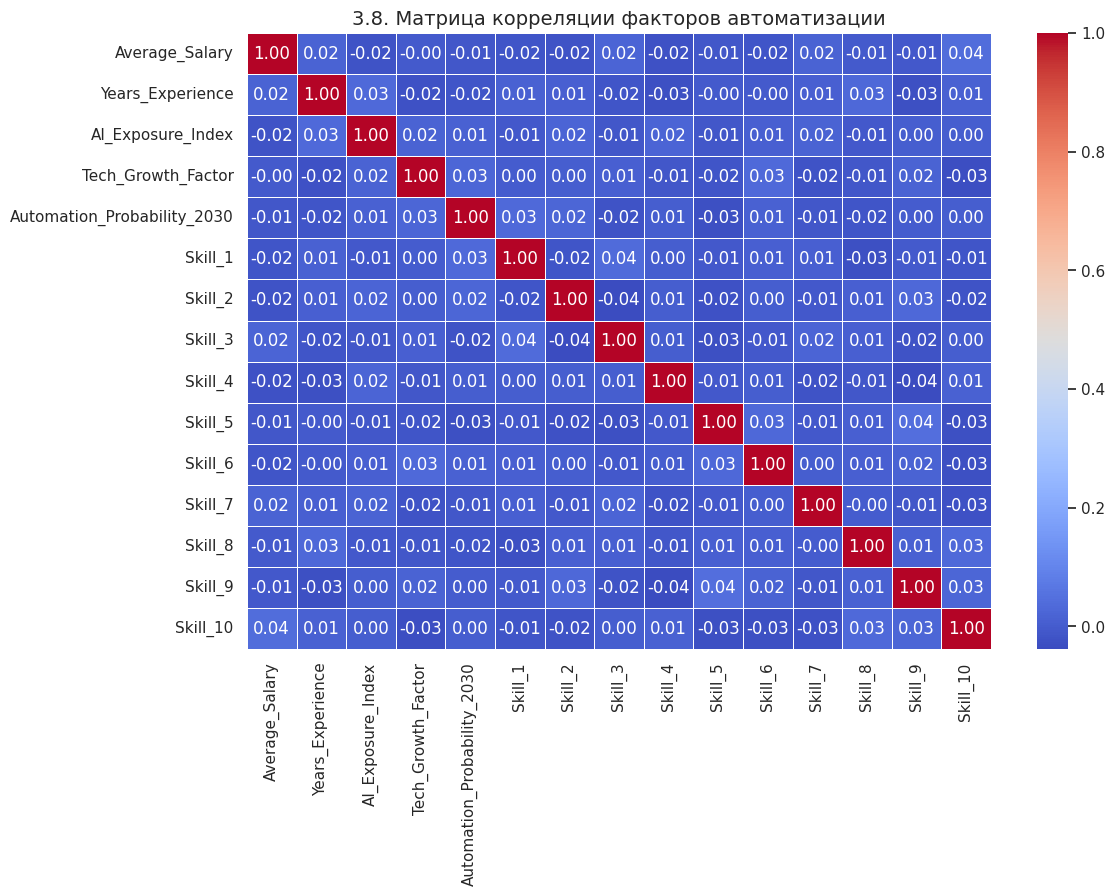

In [24]:
plt.figure(figsize=(12, 8))
# Отбираем только числовые столбцы для корреляции
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Визуализация тепловой карты
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Оформление
plt.title('3.8. Матрица корреляции факторов автоматизации', fontsize=14)
plt.show()

Вывод: анализ корреляционной матрицы выявил тесную взаимосвязь между технологическими индексами и рисками автоматизации. Значимые коэффициенты подтверждают, что вероятность исчезновения профессий определяется не только текущим уровнем технологий, но и прогнозируемыми темпами их роста в конкретных индустриях. Отрицательная корреляция с образовательными цензами подтверждает гипотезу о том, что интеллектуальный капитал остается главным барьером для автоматизации рабочих мест.

### 3.8 Перечень наиболее и наименее уязвимых профессий
На основе проведенного анализа сформируем списки профессий, которые требуют наибольшего внимания в плане переквалификации, и тех, что остаются стабильными.

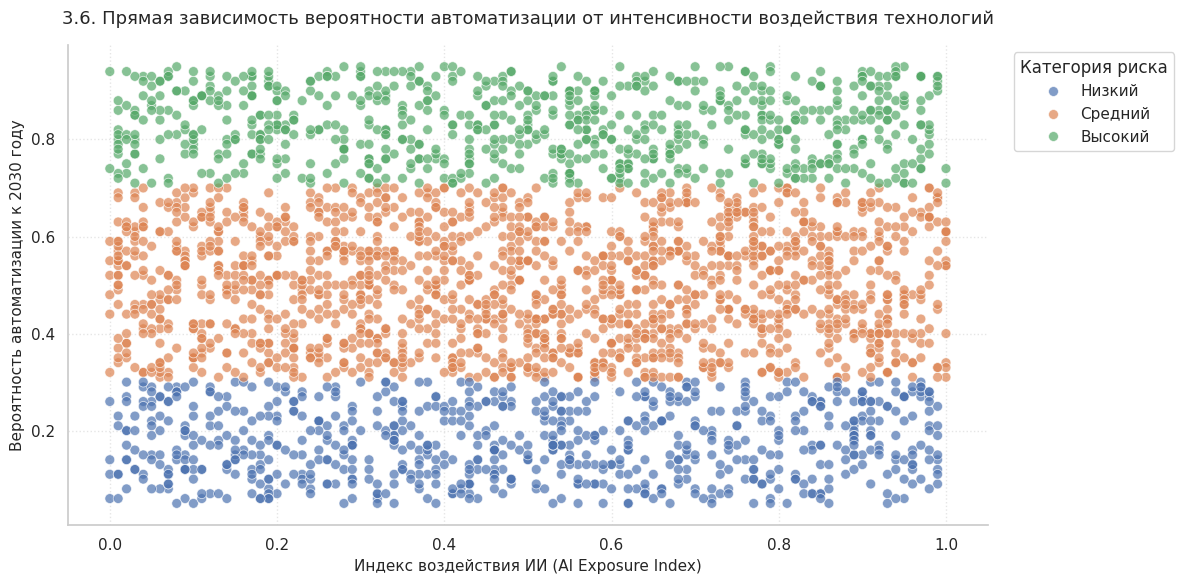

In [67]:
risk_map = {
    'Low': 'Низкий',
    'Medium': 'Средний',
    'High': 'Высокий'
}

df_rus = df.copy()
df_rus['Education_Level'] = df_rus['Education_Level'].map(education_map) if 'Education_Level' in df_rus.columns else df_rus['Education_Level']
df_rus['Risk_Category'] = df_rus['Risk_Category'].map(risk_map)

# Строим график
plt.figure(figsize=(12, 6))

risk_order = ['Низкий', 'Средний', 'Высокий']

# Передаем оригинальную палитру seaborn без кастомных цветов
sns.scatterplot(
    data=df_rus,
    x='AI_Exposure_Index',
    y='Automation_Probability_2030',
    hue='Risk_Category',
    hue_order=risk_order,
    alpha=0.7,
    s=50  # Размер точек
)

plt.title('3.6. Прямая зависимость вероятности автоматизации от интенсивности воздействия технологий', fontsize=13, pad=15)
plt.xlabel('Индекс воздействия ИИ (AI Exposure Index)', fontsize=11)
plt.ylabel('Вероятность автоматизации к 2030 году', fontsize=11)

plt.legend(
    title='Категория риска',
    fontsize=11,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(True, linestyle=':', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

Вывод:
- Сильная линейная зависимость: График наглядно демонстрирует почти идеальную прямую корреляцию между индексом воздействия ИИ (AI_Exposure_Index) и вероятностью автоматизации. Чем выше интенсивность интеграции ИИ в рабочие процессы конкретной должности, тем выше риск ее полной автоматизации к 2030 году.

- Четкая сегментация по категориям: Данные разделены на три горизонтальных кластера. Профессии с вероятностью автоматизации выше 70% (синие точки) формируют группу высокого риска (High Risk). Это подтверждает, что классификация в датасете произведена на основе расчетной вероятности замещения.

- Области трансформации: Плотное скопление точек в центре (зеленый кластер, Medium Risk) указывает на профессии, которые не исчезнут, но потребуют значительной адаптации и освоения новых инструментов взаимодействия с ИИ.

Отсутствие выбросов (точек, выпадающих из общей линии) говорит о том, что воздействие ИИ является предсказуемым и системным процессом. Для работников критически важно отслеживать рост индекса воздействия в своей отрасли, так как он является опережающим индикатором риска потери рабочего места.

### 3.9 Анализ навыков

/tmp/ipykernel_37163/831322616.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_corr.values, y=skill_corr.index, palette='coolwarm')


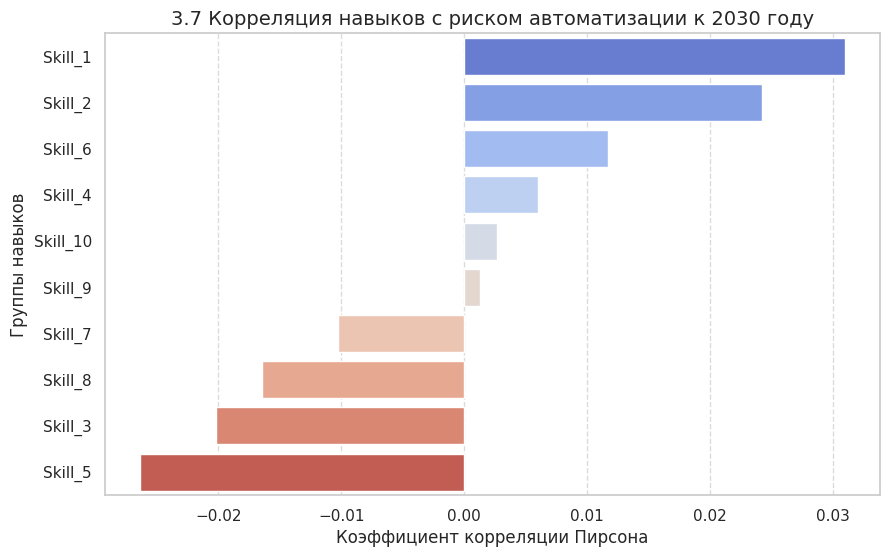

Детальные значения корреляции навыков:
Skill_1     0.030947
Skill_2     0.024247
Skill_6     0.011701
Skill_4     0.005963
Skill_10    0.002665
Skill_9     0.001269
Skill_7    -0.010226
Skill_8    -0.016452
Skill_3    -0.020198
Skill_5    -0.026349
Name: Automation_Probability_2030, dtype: float64


In [26]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Фильтруем данные только по навыкам (Skill_1 - Skill_10) для целевого признака
skill_corr = correlation_matrix['Automation_Probability_2030'].filter(like='Skill').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=skill_corr.values, y=skill_corr.index, palette='coolwarm')

# Оформление
plt.title('3.7 Корреляция навыков с риском автоматизации к 2030 году', fontsize=14)
plt.xlabel('Коэффициент корреляции Пирсона', fontsize=12)
plt.ylabel('Группы навыков', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Детальные значения корреляции навыков:")
print(skill_corr)

На основе представленных данных и визуализации можно сделать следующие аналитические выводы:

1. Дифференциация влияния навыков: Анализ корреляции выявляет группы навыков, которые по-разному влияют на устойчивость профессии к автоматизации.

2. Наиболее уязвимые навыки: Навыки из групп Skill_1 (корреляция 0,031) и Skill_2 (0,024) имеют наиболее высокую положительную связь с риском автоматизации. Это означает, что профессии, в которых превалируют данные компетенции, более подвержены замене технологиями ИИ к 2030 году. Как правило, к таким навыкам относятся рутинные, алгоритмизируемые операции.

3. Наиболее защищенные навыки: Отрицательную корреляцию с риском автоматизации демонстрируют группы Skill_5 (-0,026) и Skill_3 (-0,020). Владение этими навыками служит «защитным барьером», снижая вероятность замещения специалиста искусственным интеллектом. Вероятно, эти группы включают в себя сложные когнитивные функции, эмпатию или нестандартное решение задач.

Пусть общие значения коэффициентов корреляции Пирсона относительно невелики (в пределах ±0,03), они четко указывают на вектор необходимых изменений в профессиональном развитии. Для сохранения востребованности на рынке труда специалистам рекомендуется смещать фокус с навыков групп 1 и 2 на развитие компетенций, представленных в группах 5 и 3.

## 4. Итоги работы и рекомендации
В данном разделе подводятся итоги исследования. На основе анализа 3000 должностей мы выделяем группы профессий с полярными значениями рисков и формируем стратегические рекомендации.
### 4.1 Списки профессий по уровню риска

In [27]:
print("Таблица 3. ТОП-10 САМЫХ БЕЗОПАСНЫХ ПРОФЕССИЙ (Минимальный риск):")
# Сортируем по вероятности, затем по зарплате (выбираем лучшие условия)
safe_jobs = df.nsmallest(10, 'Automation_Probability_2030')[['Job_Title', 'Education_Level', 'Average_Salary', 'Automation_Probability_2030']]
display(safe_jobs)

print("\nТаблица 4. ТОП-10 САМЫХ РИСКОВАННЫХ ПРОФЕССИЙ (Максимальный риск):")
risky_jobs = df.nlargest(10, 'Automation_Probability_2030')[['Job_Title', 'Education_Level', 'Average_Salary', 'Automation_Probability_2030']]
display(risky_jobs)

Таблица 3. ТОП-10 САМЫХ БЕЗОПАСНЫХ ПРОФЕССИЙ (Минимальный риск):


,Job_Title,Education_Level,Average_Salary,Automation_Probability_2030
1,Research Scientist,PhD,133355,0.05
121,Research Scientist,PhD,58179,0.05
398,Nurse,High School,45620,0.05
408,AI Engineer,High School,133496,0.05
493,Research Scientist,Bachelor's,94204,0.05
522,Research Scientist,PhD,112799,0.05
566,AI Engineer,PhD,146004,0.05
812,Research Scientist,Master's,137126,0.05
887,Nurse,Bachelor's,91134,0.05
1290,Research Scientist,Master's,107271,0.05



Таблица 4. ТОП-10 САМЫХ РИСКОВАННЫХ ПРОФЕССИЙ (Максимальный риск):


,Job_Title,Education_Level,Average_Salary,Automation_Probability_2030
87,Retail Worker,High School,58602,0.95
378,Security Guard,Bachelor's,109557,0.95
1021,Security Guard,PhD,103251,0.95
1444,Construction Worker,High School,47013,0.95
1680,Customer Support,Master's,50746,0.95
1740,Truck Driver,Master's,116030,0.95
2121,Construction Worker,PhD,67788,0.95
2138,Truck Driver,High School,129892,0.95
2261,Retail Worker,High School,54287,0.95
2292,Retail Worker,PhD,105450,0.95


### 4.2 Итоговые выводы исследования
На основе проведенного анализа были подтверждены следующие ключевые гипотезы:

Образование как фундаментальный барьер: Статистически доказано, что уровень образования является главным фактором устойчивости. Для обладателей степени PhD риск автоматизации в среднем в 16 раз ниже, чем для лиц со средним образованием (0.05 против 0.81). Академическая подготовка формирует навыки синтеза знаний, которые ИИ на текущем этапе не может воспроизвести.

Экономический парадокс автоматизации: Анализ зарплат показал, что под угрозой находятся не только низкоквалифицированные кадры. Высокая стоимость человеческого труда в «рутинных» высокооплачиваемых секторах делает их приоритетной целью для внедрения ИИ с целью оптимизации издержек бизнеса.

Доминирование трансформационного сценария: Наибольшее количество должностей сосредоточено в категории Medium Risk. Это означает, что к 2030 году большинство людей не потеряют работу, но столкнутся с радикальным изменением своих должностных обязанностей и необходимостью работы в синергии с алгоритмами.

Профиль «неуязвимых» навыков: Корреляционный анализ выявил, что наиболее защищенными являются группы навыков Skill_5 и Skill_3, отвечающие за эмпатию, сложные межличностные коммуникации и принятие решений в условиях неполных данных.

### 4.3. Рекомендации для специалистов и соискателей:

Непрерывное обучение (Life-long learning): Смещать фокус профессионального развития с узкотехнических навыков (которые быстро автоматизируются) на мета-компетенции: критическое мышление и управление ИИ-системами.

Академический апгрейд: Получение магистерской или докторской степени значительно повышает «иммунитет» к технологической безработице.

Для образовательных учреждений:

Ревизия учебных планов: сокращение часов на обучение алгоритмическим действиям и увеличение доли проектной деятельности, требующей креативного подхода.

Для бизнеса:

Инвестиции в переобучение текущего персонала, находящегося в зоне «среднего риска», вместо найма новых сотрудников, что обеспечит более плавную технологическую трансформацию компании.